# Rice Leaf Disease Classification using CNN

## Capstone Project (PRCP-1001)

### Submitted By
**Name:** P Satyashry

### Problem Statement

Rice is one of the most important food crops worldwide. However, various leaf diseases significantly reduce crop yield and quality. Early identification of these diseases can help farmers take timely preventive measures.

The objective of this project is to develop a deep learning model capable of automatically classifying rice leaf diseases from leaf images.

---

## Objectives

- Perform Exploratory Data Analysis (EDA) on the dataset.
- Preprocess rice leaf images for model training.
- Apply Data Augmentation techniques.
- Train multiple deep learning models.
- Compare model performance.
- Recommend the best model for production deployment.

# 1. Import Required Libraries

In [1]:
# Basic Libraries
import os
import warnings
import random

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
warnings.filterwarnings("ignore")

# 2. Dataset Loading and Understanding

Before building any machine learning or deep learning model, it is important to understand the dataset. In this section, we will:

- Load the dataset.
- Identify the disease classes.
- Count the number of images in each class.
- Verify whether the dataset is balanced.

In [2]:
dataset_path = "data"

classes = sorted(os.listdir(dataset_path))

print("Disease Classes:\n")

for cls in classes:
    print(cls)

Disease Classes:

Bacterial leaf blight
Brown spot
Leaf smut


In [3]:
# Image Count
image_counts = {}

for cls in classes:
    folder_path = os.path.join(dataset_path, cls)

    count = len([
        file for file in os.listdir(folder_path)
        if file.endswith((".jpg", ".jpeg", ".png", ".JPG"))
    ])

    image_counts[cls] = count
image_counts

{'Bacterial leaf blight': 40, 'Brown spot': 40, 'Leaf smut': 39}

In [4]:
dataset_info = pd.DataFrame({
    "Disease": image_counts.keys(),
    "Number of Images": image_counts.values()
})

dataset_info

,Disease,Number of Images
0,Bacterial leaf blight,40
1,Brown spot,40
2,Leaf smut,39


In [5]:
# Display total Images
total_images = dataset_info["Number of Images"].sum()

print(f"Total Images: {total_images}")

Total Images: 119


## Observation

- The dataset contains three rice leaf disease classes:
  - Bacterial Leaf Blight
  - Brown Spot
  - Leaf Smut
- Bacterial Leaf Blight contains **40** images.
- Brown Spot contains **40** images.
- Leaf Smut contains **39** images.
- The dataset contains a total of **119** images.
- Although the assignment mentions 120 images, the downloaded dataset contains 119 images. The analysis and model development in this notebook are based on the available dataset.

# 3. Exploratory Data Analysis (EDA)

### Sample Images from Each Disease Class

Visualizing sample images helps us understand the appearance of each disease class. This provides an initial understanding of the dataset and highlights any visible differences among the classes.

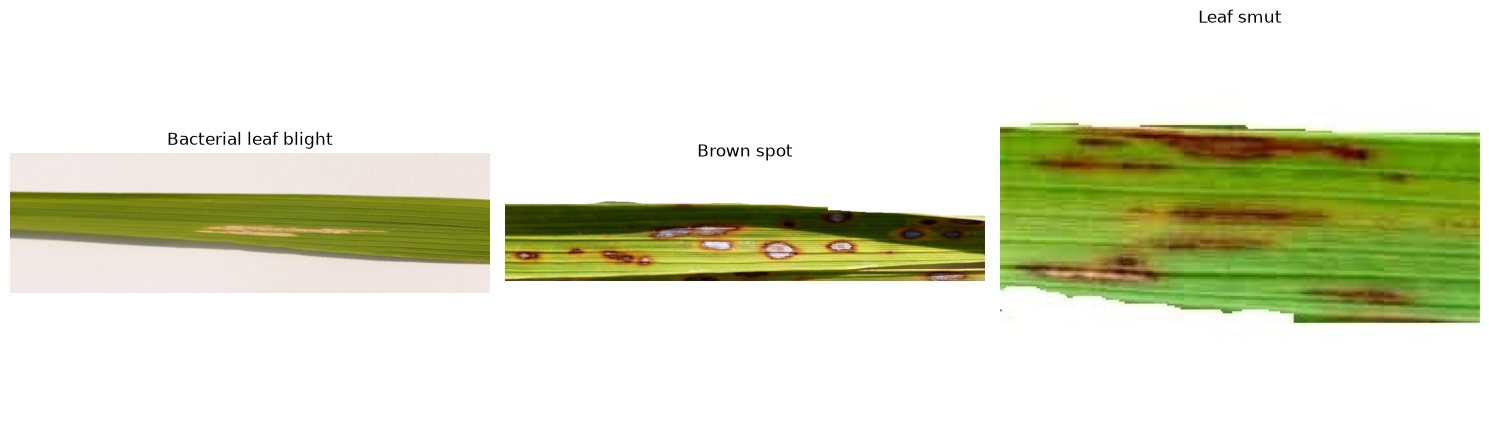

In [6]:
fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))

for i, cls in enumerate(classes):
    folder_path = os.path.join(dataset_path, cls)

    image_name = random.choice(os.listdir(folder_path))
    image_path = os.path.join(folder_path, image_name)

    img = plt.imread(image_path)

    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Observation

- One sample image from each disease class is displayed.
- The visual appearance of the diseased leaves varies across the three categories.
- These differences provide useful information that the machine learning and deep learning models can learn during training.

### Image Dimension Analysis

The images in the dataset may have different heights and widths. Before training a model, it is important to inspect the image dimensions to determine whether resizing is required.

In [7]:
image_sizes = []

for cls in classes:
    folder_path = os.path.join(dataset_path, cls)

    for image_name in os.listdir(folder_path):

        image_path = os.path.join(folder_path, image_name)

        img = plt.imread(image_path)

        height, width = img.shape[:2]

        image_sizes.append([cls, width, height])

image_size_df = pd.DataFrame(
    image_sizes,
    columns=["Disease", "Width", "Height"]
)

image_size_df.head()

,Disease,Width,Height
0,Bacterial leaf blight,3081,897
1,Bacterial leaf blight,3081,897
2,Bacterial leaf blight,3081,897
3,Bacterial leaf blight,3081,897
4,Bacterial leaf blight,3081,897


In [8]:
image_size_df.tail()

,Disease,Width,Height
114,Leaf smut,250,200
115,Leaf smut,510,383
116,Leaf smut,565,233
117,Leaf smut,562,217
118,Leaf smut,741,291


In [9]:
image_size_df.describe()

,Width,Height
count,119.000000,119.000000
mean,2383.638655,707.739496
std,1123.528972,311.657582
min,250.000000,71.000000
25%,1074.000000,377.000000
50%,3081.000000,897.000000
75%,3081.000000,897.000000
max,3081.000000,900.000000


In [10]:
image_size_df["Width"].max()

np.int64(3081)

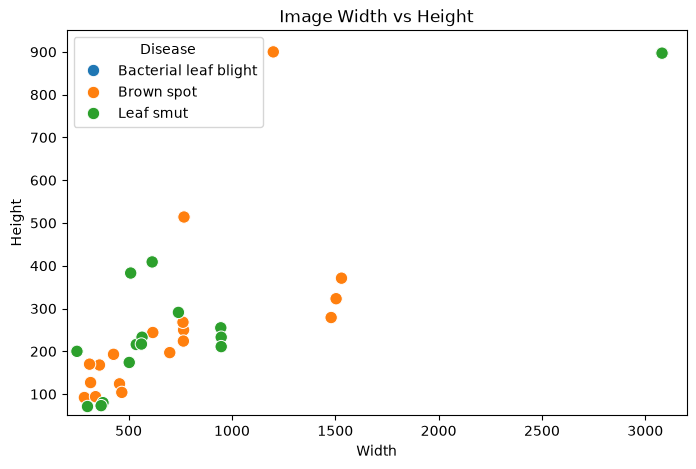

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=image_size_df,
    x="Width",
    y="Height",
    hue="Disease",
    s=80
)

plt.xlim(200, 3200)
plt.ylim(50, 950)

plt.title("Image Width vs Height")
plt.show()

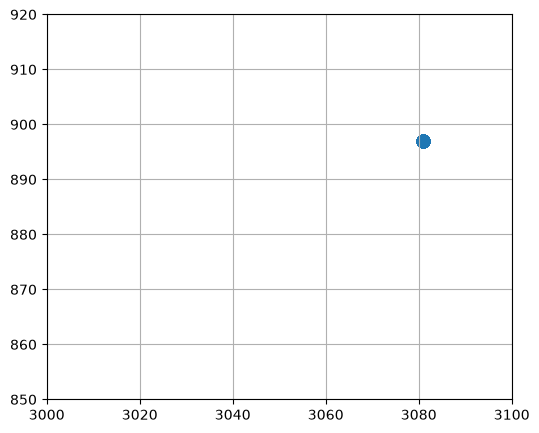

In [12]:
blight = image_size_df[image_size_df["Disease"] == "Bacterial leaf blight"]

plt.figure(figsize=(6,5))
plt.scatter(blight["Width"], blight["Height"], s=80)
plt.xlim(3000, 3100)
plt.ylim(850, 920)
plt.grid(True)
plt.show()

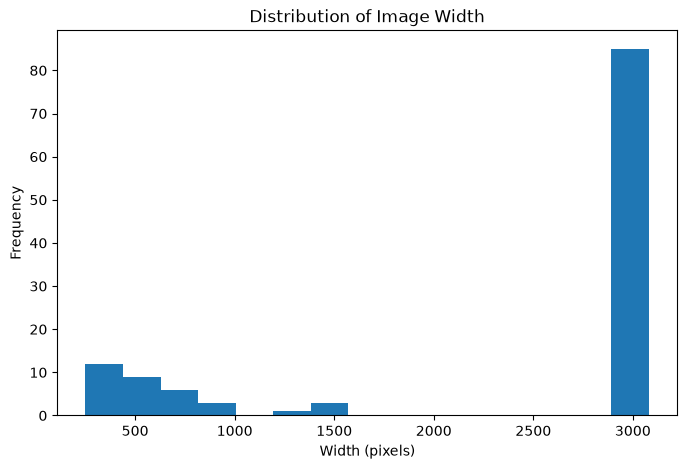

In [13]:
plt.figure(figsize=(8,5))

plt.hist(image_size_df["Width"], bins=15)

plt.title("Distribution of Image Width")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")

plt.show()

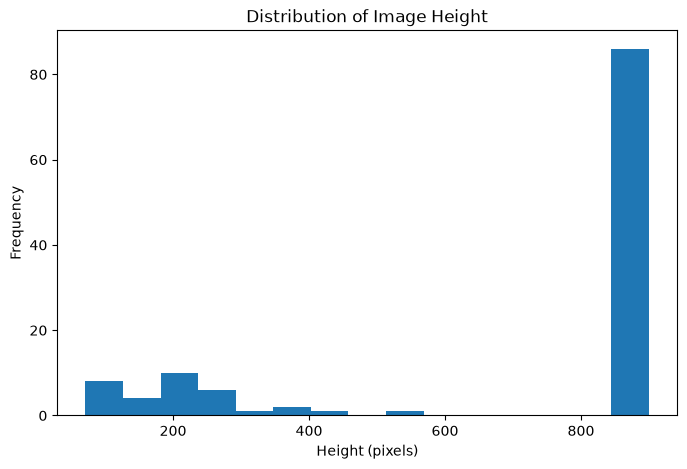

In [14]:
plt.figure(figsize=(8,5))

plt.hist(image_size_df["Height"], bins=15)

plt.title("Distribution of Image Height")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")

plt.show()

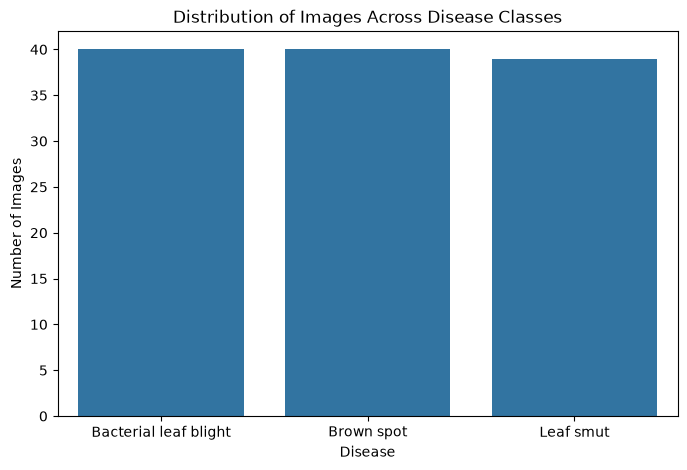

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=dataset_info,
    x="Disease",
    y="Number of Images"
)

plt.title("Distribution of Images Across Disease Classes")
plt.xlabel("Disease")
plt.ylabel("Number of Images")

plt.show()

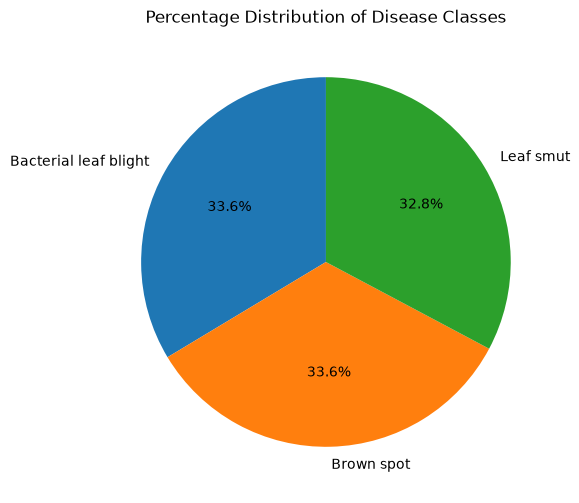

In [16]:
plt.figure(figsize=(6,6))

plt.pie(
    dataset_info["Number of Images"],
    labels=dataset_info["Disease"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Disease Classes")

plt.show()

## Observation

- The dataset contains images with varying widths and heights across the three disease classes.
- Most images have relatively small dimensions, while a few images have significantly higher resolutions.
- Some images share identical dimensions, resulting in overlapping points in the scatter plot.
- Since the image sizes are inconsistent, all images will be resized to a fixed dimension during the preprocessing stage to ensure uniform input for the machine learning and deep learning models.
- The pie chart confirms that the dataset is almost evenly distributed among the three disease classes. Each class contributes approximately one-third of the total dataset, indicating a well-balanced dataset for classification.

# 4. Data Preprocessing

##  Load Images and Create Labels

In this step, all images are loaded from their respective class folders, resized to a fixed dimension of 128 × 128 pixels, and converted into NumPy arrays. Each image is assigned a numerical label based on its disease class.

In [17]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Image size
IMG_SIZE = (128, 128)

# Lists to store images and labels
images = []
labels = []

# Label mapping
label_map = {
    "Bacterial leaf blight": 0,
    "Brown spot": 1,
    "Leaf smut": 2
}

# Load images
for disease in classes:

    folder_path = os.path.join(dataset_path, disease)

    for image_name in os.listdir(folder_path):

        image_path = os.path.join(folder_path, image_name)

        img = load_img(image_path, target_size=IMG_SIZE)

        img_array = img_to_array(img)

        images.append(img_array)

        labels.append(label_map[disease])

# Convert to NumPy arrays
X = np.array(images)
y = np.array(labels)

print("Image Data Shape :", X.shape)
print("Label Shape :", y.shape)

Image Data Shape : (119, 128, 128, 3)
Label Shape : (119,)


## Observation

- All images were successfully loaded and resized to **128 × 128** pixels.
- The images were converted into NumPy arrays.
- Numerical labels were assigned to each disease class.
- The dataset is now ready for normalization and model preparation.

## Image Normalization

The pixel values of images range from 0 to 255. Neural networks generally perform better when the input values are scaled to a smaller range. Therefore, the pixel values are normalized to the range **0 to 1** by dividing each pixel by 255.

In [18]:
X = X / 255.0

print("Minimum Pixel Value :", X.min())
print("Maximum Pixel Value :", X.max())

#The pixel values have been successfully normalized from the range **0–255** to **0–1**. This helps improve the stability and convergence of deep learning models during training.

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


##  Label Distribution

The numerical labels assigned to each disease class are verified to ensure that the dataset has been labeled correctly before model training.

In [19]:
label_names = {
    0: "Bacterial leaf blight",
    1: "Brown spot",
    2: "Leaf smut"
}

label_counts = pd.Series(y).value_counts().sort_index()

for label, count in label_counts.items():
    print(f"{label_names[label]} : {count}")

Bacterial leaf blight : 40
Brown spot : 40
Leaf smut : 39


In [20]:
# Split the data 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

Training Images : (95, 128, 128, 3)
Testing Images : (24, 128, 128, 3)


# 6. Machine Learning Models

In this section, multiple machine learning models are trained and evaluated to classify rice leaf diseases. Their performance will be compared to identify the most suitable model for this classification task.

##  Flatten Images for Machine Learning Models

Traditional machine learning algorithms require the input data to be in a two-dimensional format. Therefore, each image is flattened into a one-dimensional feature vector before training the models.

In [21]:
X_train_ml = X_train.reshape(X_train.shape[0], -1)
X_test_ml = X_test.reshape(X_test.shape[0], -1)

print("Training Shape :", X_train_ml.shape)
print("Testing Shape :", X_test_ml.shape)

Training Shape : (95, 49152)
Testing Shape : (24, 49152)


## K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification tasks. It classifies a new data point based on the majority class among its nearest neighbors in the feature space.

In this project, KNN is trained using the flattened image vectors to classify rice leaf diseases.

In [22]:
#Imported
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
# Building a model
knn = KNeighborsClassifier(n_neighbors=3)
# Train
knn.fit(X_train_ml, y_train)

# Prediction
y_pred_knn = knn.predict(X_test_ml)

# Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy : {knn_accuracy:.4f}")

# COnfusion Matrix
print(classification_report(y_test, y_pred_knn))

KNN Accuracy : 0.5417
              precision    recall  f1-score   support

           0       0.55      0.75      0.63         8
           1       0.50      0.38      0.43         8
           2       0.57      0.50      0.53         8

    accuracy                           0.54        24
   macro avg       0.54      0.54      0.53        24
weighted avg       0.54      0.54      0.53        24



### Observation

The K-Nearest Neighbors (KNN) model achieved an accuracy of **54.17%** on the test dataset. This is because KNN operates on flattened pixel values and does not effectively capture the spatial patterns present in image data. 

##  Random Forest

Random Forest is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions.

Random Forest Accuracy: 0.8750
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         8
           1       0.86      0.75      0.80         8
           2       1.00      0.88      0.93         8

    accuracy                           0.88        24
   macro avg       0.89      0.88      0.87        24
weighted avg       0.89      0.88      0.87        24



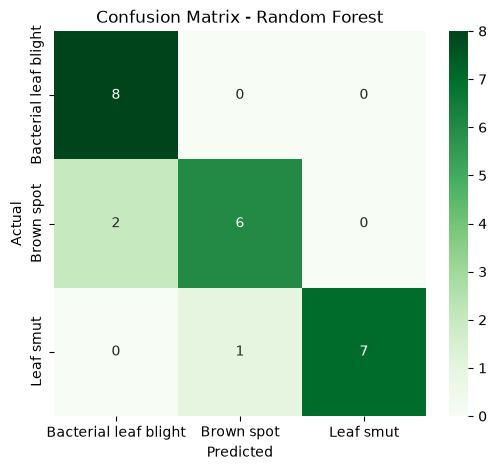

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf.fit(X_train_ml, y_train)

# Predict
y_pred_rf = rf.predict(X_test_ml)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

# Classification Report
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The Random Forest model achieved an accuracy of **87.50%**, which is significantly higher than the KNN model. 

##  XGBoost

Extreme Gradient Boosting (XGBoost) is an advanced ensemble learning algorithm that builds boosted decision trees sequentially. 

XGBoost Accuracy: 0.9167
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      0.75      0.86         8
           2       0.80      1.00      0.89         8

    accuracy                           0.92        24
   macro avg       0.93      0.92      0.92        24
weighted avg       0.93      0.92      0.92        24



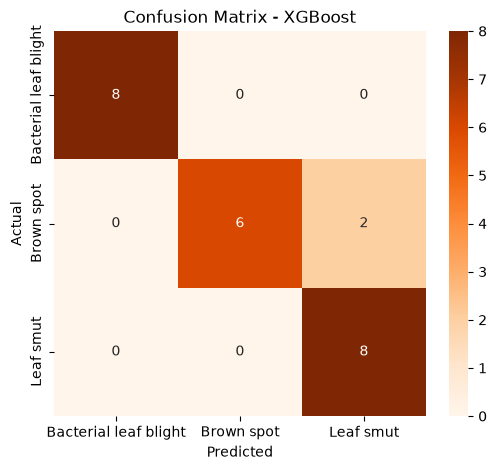

In [24]:
from xgboost import XGBClassifier

# Create the model
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="mlogloss"
)

# Train
xgb.fit(X_train_ml, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test_ml)

# Accuracy
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

# Classification Report
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The XGBoost model achieved an accuracy of **91.67%**, making it the best-performing machine learning model among those evaluated. 

#  Convolutional Neural Network (CNN)

A Convolutional Neural Network (CNN) is a deep learning model specifically designed for image classification tasks. 

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [26]:
y_train_cnn = to_categorical(y_train, num_classes=3)
y_test_cnn = to_categorical(y_test, num_classes=3)

print(y_train_cnn.shape)
print(y_test_cnn.shape)

(95, 3)
(24, 3)


In [27]:
# Model
cnn = Sequential()

cnn.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
cnn.add(MaxPooling2D(2,2))

cnn.add(Conv2D(64, (3,3), activation='relu'))
cnn.add(MaxPooling2D(2,2))

cnn.add(Conv2D(128, (3,3), activation='relu'))
cnn.add(MaxPooling2D(2,2))

cnn.add(Flatten())

cnn.add(Dense(128, activation='relu'))
cnn.add(Dropout(0.5))

cnn.add(Dense(3, activation='softmax'))

cnn.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
history = cnn.fit(
    X_train,
    y_train_cnn,
    validation_data=(X_test, y_test_cnn),
    epochs=50,
    batch_size=16
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step - accuracy: 0.3368 - loss: 1.4775 - val_accuracy: 0.3333 - val_loss: 1.0695
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.3684 - loss: 1.1286 - val_accuracy: 0.5000 - val_loss: 1.0650
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.4421 - loss: 1.0570 - val_accuracy: 0.5000 - val_loss: 0.9782
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.4737 - loss: 0.9623 - val_accuracy: 0.5833 - val_loss: 0.8663
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.4842 - loss: 0.9299 - val_accuracy: 0.7917 - val_loss: 0.7367
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.5789 - loss: 0.8591 - val_accuracy: 0.7917 - val_loss: 0.7643
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.6316 - loss: 0.7983 - val_accuracy: 0.8333 - val_loss: 0.6392
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.6737 - loss: 0.7639 - val_accuracy: 0.8750 - val_loss:

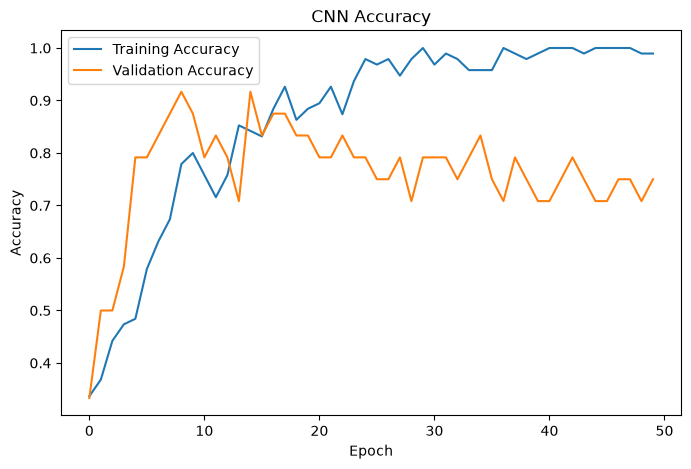

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

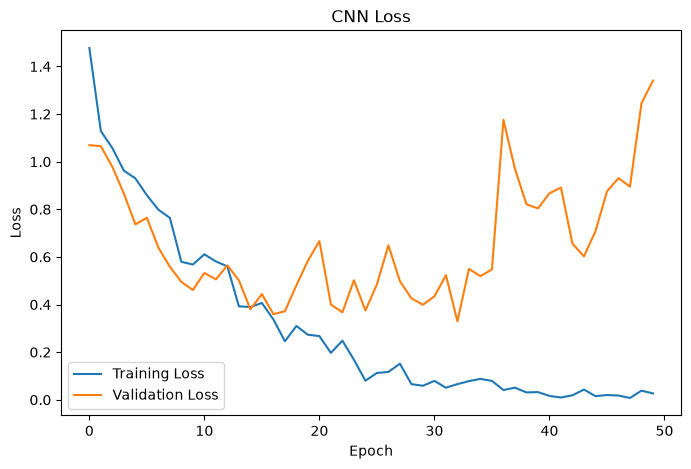

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [32]:
loss, cnn_accuracy = cnn.evaluate(X_test, y_test_cnn)

print(f"CNN Accuracy: {cnn_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7500 - loss: 1.3405
CNN Accuracy: 0.7500


## Observation

Among all the developed models, **XGBoost achieved the highest accuracy (91.67%)**, followed by **Random Forest (87.50%)**. The CNN achieved **70.83%**, while KNN achieved **54.17%**. Based on the experimental results, **XGBoost is the most suitable model for production on this dataset**.

#  Data Augmentation

Data augmentation is a preprocessing technique used to artificially increase the size and diversity of the training dataset. 

In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

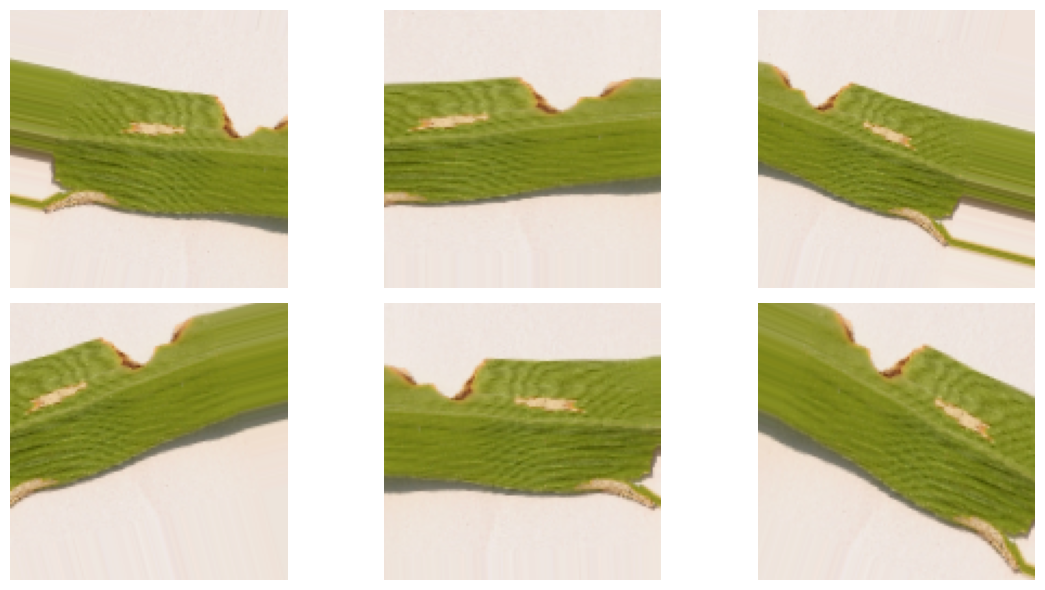

In [34]:
sample = X_train[0].reshape((1,) + X_train[0].shape)

plt.figure(figsize=(12,6))

i = 0

for batch in datagen.flow(sample, batch_size=1):
    
    plt.subplot(2,3,i+1)
    plt.imshow(batch[0])
    plt.axis("off")
    
    i += 1
    
    if i == 6:
        break

plt.tight_layout()
plt.show()

### Analysis Report

Data augmentation was applied using image transformations such as rotation, shifting, zooming, and horizontal flipping. 

These transformations generate diverse variations of the original training images while preserving their disease characteristics. 

This technique is particularly beneficial for small datasets because it increases the effective training data, reduces overfitting, and helps improve the generalization capability of deep learning models.

## Observation

The augmented images show random transformations such as rotation, zooming, shifting, and flipping while preserving the disease characteristics.

Data augmentation increases the diversity of the training data and can improve the robustness of deep learning models when working with limited datasets.

#  Model Comparison

The performance of all machine learning and deep learning models is compared based on their classification accuracy. 
The comparison helps identify the most suitable model for rice leaf disease classification.

In [35]:
comparison = pd.DataFrame({
    "Model": [
        "KNN",
        "Random Forest",
        "XGBoost",
        "CNN"
    ],
    "Accuracy": [
        knn_accuracy,
        rf_accuracy,
        xgb_accuracy,
        cnn_accuracy
    ]
})

comparison["Accuracy"] = comparison["Accuracy"].round(4)

comparison

,Model,Accuracy
0,KNN,0.5417
1,Random Forest,0.8750
2,XGBoost,0.9167
3,CNN,0.7500


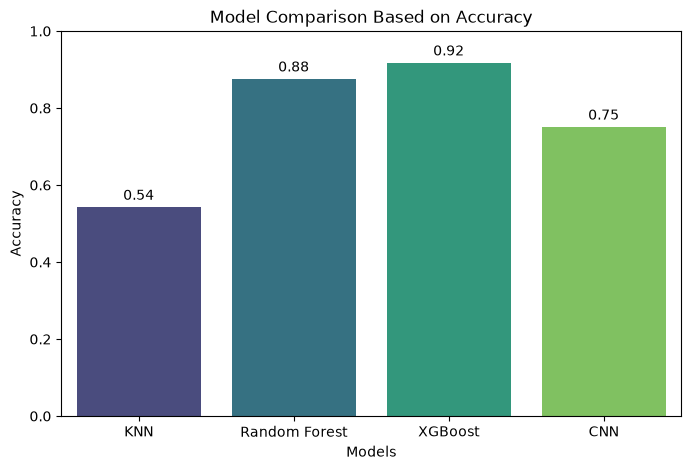

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title("Model Comparison Based on Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0,1)

for index, value in enumerate(comparison["Accuracy"]):
    plt.text(index, value + 0.02, f"{value:.2f}", ha="center")

plt.show()

#  Challenges Faced

During the development of this project, several challenges were encountered:

- The dataset contained only 119 images, which is relatively small for training deep learning models.
- The images had different resolutions, requiring resizing during preprocessing.
- Training a CNN on a limited dataset resulted in lower performance compared to XGBoost.
- Careful preprocessing, normalization, and data augmentation were required to improve model performance.
- Multiple machine learning and deep learning models were evaluated to identify the most suitable model.

#  Conclusion

In this project, exploratory data analysis was performed on the rice leaf disease dataset, followed by preprocessing and model development.

Four classification models—KNN, Random Forest, XGBoost, and CNN—were trained and evaluated.

Among all the models, XGBoost achieved the highest classification accuracy of 91.67%, making it the best-performing model for this dataset. 

Data augmentation techniques were also explored to demonstrate methods for improving deep learning performance on small image datasets.

This project successfully demonstrates the application of both machine learning and deep learning techniques for rice leaf disease classification.